# Approach 1: MapperPlus + Caracterización con Tablas de Fenton

### Imports

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DFE_FACTOR = 1.7

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


### En esta celda hacemos la elección de los features que entrarán al clústering
En este approach decidimos utilizar sólo indicadores diferenciados del consumo de ácido fólico de las madres

In [3]:
df = pd.read_csv("C:/Users/anduj/Documents/tecnologico_de_monterrey/topo/tda_project/data/clean/dataset2_limpio.csv")
df_ohe = pd.read_csv("C:/Users/anduj/Documents/tecnologico_de_monterrey/topo/tda_project/data/clean/dataset2_limpio_ohe.csv")

print("df     :", df.shape)
print("df_ohe :", df_ohe.shape)

# ── Espacios de features (en mgAF, tal como vienen) ──────────────────
AF_DOSIS_AF = [
    "mgAF/día SAF",
    "mgAF/día MAF 1°T",
    "mgAF/día OSAF 1°T",
    "mg/d AF total pan",
    "Total mg/d AF  suple y pan",
    "TOTAL AF mg suplementos y multivitamínicos período ",
]
AF_DURACION = [
    "Días consumo suplementosAF",
    "Días consumo MAF",
]

OUTCOME_FEATURES = [
    "PN hijo (g)", "EG hijo (sem)", "Dif peso mamá",
    "IMC después", "Dif IMC", "¿Hijo nace c/problema de salud?",
]
CONTROL_VARS = [
    "Edad madre", "Educación", "IMC antes",
    "Condición mamá", "N° embarazo", "Región",
]

# ── Construcción del espacio en DFE (folatos) ────────────────────────
# Convertimos las DOSIS de AF -> DFE (×1.7). Las DURACIONES no se convierten.
AF_DFE = []
for col in AF_DOSIS_AF:
    new = col.replace("AF", "DFE").replace("mg/d", "mg/d DFE") + " [DFE]"
    df[new] = df[col] * DFE_FACTOR
    AF_DFE.append(new)

# Espacio de features que entra al clustering: dosis en DFE + duraciones
FEATURES_DFE = AF_DFE + AF_DURACION

print("\nFeatures que entran al clustering (DFE + duración):")
for c in FEATURES_DFE:
    print("  ", c)

print("\nResumen del espacio de features (DFE):")
print(df[FEATURES_DFE].describe().round(3).T[["mean","std","min","max"]])

df     : (705, 67)
df_ohe : (705, 180)

Features que entran al clustering (DFE + duración):
   mgDFE/día SDFE [DFE]
   mgDFE/día MDFE 1°T [DFE]
   mgDFE/día OSDFE 1°T [DFE]
   mg/d DFE DFE total pan [DFE]
   Total mg/d DFE DFE  suple y pan [DFE]
   TOTAL DFE mg suplementos y multivitamínicos período  [DFE]
   Días consumo suplementosAF
   Días consumo MAF

Resumen del espacio de features (DFE):
                                                       mean      std    min       max
mgDFE/día SDFE [DFE]                                  3.147    3.345  0.000     8.500
mgDFE/día MDFE 1°T [DFE]                              0.135    0.392  0.000     2.720
mgDFE/día OSDFE 1°T [DFE]                             0.075    0.461  0.000     3.400
mg/d DFE DFE total pan [DFE]                          0.311    0.172  0.000     1.173
Total mg/d DFE DFE  suple y pan [DFE]                 4.023    3.409  0.042    13.192
TOTAL DFE mg suplementos y multivitamínicos per...  522.991  635.533  0.000  2984.520


In [4]:
df = df.drop(columns=[c for c in df.columns if c.endswith("[DFE]")])

DFE_RENAME = {
    "mgAF/día SAF":                                          "mgDFE/día SAF",
    "mgAF/día MAF 1°T":                                      "mgDFE/día MAF 1°T",
    "mgAF/día OSAF 1°T":                                     "mgDFE/día OSAF 1°T",
    "mg/d AF total pan":                                     "mgDFE/d pan",
    "Total mg/d AF  suple y pan":                            "Total mgDFE/d suple+pan",
    "TOTAL AF mg suplementos y multivitamínicos período ":  "TOTAL DFE mg período",
}

AF_DFE = []
for orig, new in DFE_RENAME.items():
    df[new] = df[orig] * DFE_FACTOR
    AF_DFE.append(new)

FEATURES_DFE = AF_DFE + AF_DURACION

print("Features que entran al clustering (DFE + duración):")
for c in FEATURES_DFE:
    print("  ", c)

print("\nResumen del espacio de features (DFE):")
print(df[FEATURES_DFE].describe().round(3).T[["mean","std","min","max"]])

Features que entran al clustering (DFE + duración):
   mgDFE/día SAF
   mgDFE/día MAF 1°T
   mgDFE/día OSAF 1°T
   mgDFE/d pan
   Total mgDFE/d suple+pan
   TOTAL DFE mg período
   Días consumo suplementosAF
   Días consumo MAF

Resumen del espacio de features (DFE):
                               mean      std    min       max
mgDFE/día SAF                 3.147    3.345  0.000     8.500
mgDFE/día MAF 1°T             0.135    0.392  0.000     2.720
mgDFE/día OSAF 1°T            0.075    0.461  0.000     3.400
mgDFE/d pan                   0.311    0.172  0.000     1.173
Total mgDFE/d suple+pan       4.023    3.409  0.042    13.192
TOTAL DFE mg período        522.991  635.533  0.000  2984.520
Días consumo suplementosAF  139.448   88.684  0.000   287.000
Días consumo MAF            138.214   90.393  0.000   287.000


Decisión: componentes desagregados de dosis (en DFE) + 1 duración.
- Quitamos los totales (Total suple+pan, TOTAL período) por colinealidad.
- Quitamos "Días consumo MAF" (corr=1.00 con suplementosAF); dejamos una.

In [5]:
FEATURES_FINAL = [
    "mgDFE/día SAF",
    "mgDFE/día MAF 1°T",
    "mgDFE/día OSAF 1°T",
    "mgDFE/d pan",
    "Días consumo suplementosAF",
]

X_raw = df[FEATURES_FINAL].copy()
print("Espacio final de features:", X_raw.shape)
print(X_raw.describe().round(3).T[["mean","std","min","max"]])

scaler = StandardScaler()
X = scaler.fit_transform(X_raw.values)

print("\nDespués de z-score (deben ser ~0 media, ~1 std):")
print(pd.DataFrame(X, columns=FEATURES_FINAL).describe().round(3).T[["mean","std","min","max"]])

Espacio final de features: (705, 5)
                               mean     std  min      max
mgDFE/día SAF                 3.147   3.345  0.0    8.500
mgDFE/día MAF 1°T             0.135   0.392  0.0    2.720
mgDFE/día OSAF 1°T            0.075   0.461  0.0    3.400
mgDFE/d pan                   0.311   0.172  0.0    1.173
Días consumo suplementosAF  139.448  88.684  0.0  287.000

Después de z-score (deben ser ~0 media, ~1 std):
                            mean    std    min    max
mgDFE/día SAF                0.0  1.001 -0.941  1.601
mgDFE/día MAF 1°T           -0.0  1.001 -0.344  6.592
mgDFE/día OSAF 1°T           0.0  1.001 -0.162  7.224
mgDFE/d pan                 -0.0  1.001 -1.812  5.032
Días consumo suplementosAF  -0.0  1.001 -1.574  1.665


### Aquí importamos el algoritmo de MapperPlus que se encuentra público en github
para más infomración sobre el funcionamiento del algoritmo y su justificación puede consultarse el siguiente paper: https://doi.org/10.1371/journal.pdig.0000307

In [6]:
!pip install kmapper
!git clone https://github.com/lordareicgnon/Mapper_plus.git


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
fatal: destination path 'Mapper_plus' already exists and is not an empty directory.


In [7]:
import sys
sys.path.insert(0, "Mapper_plus")

import kmapper as km
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import mapper_plus
import walk_likelihood

print("MapperPlus importado correctamente")
print("Clase disponible:", hasattr(mapper_plus, "mapper_plus"))

KeplerMapper(verbose=1)
MapperPlus importado correctamente
Clase disponible: True


### Corremos el método de manera preeliminar para observar comportamiento

In [8]:
mapper = km.KeplerMapper(verbose=0)

# PASO 1 — Lens: proyección a baja dimensión.
# Empezamos con PCA a 2 componentes (lente más común e interpretable).
lens = mapper.fit_transform(X, projection=PCA(n_components=2, random_state=RANDOM_STATE))
print("Lens shape:", lens.shape)

# PASOS 2-3 — Cover (resolución r, gain g) + clusterer dentro de cada hipercubo
resolution = 6      # n_cubes: nº de hipercubos por dimensión del lens
gain       = 0.4    # perc_overlap: solapamiento (0-1)

cover     = km.Cover(n_cubes=resolution, perc_overlap=gain)
clusterer = DBSCAN(eps=0.5, min_samples=3)   # clustering parcial dentro de cada cubo

# PASO 4 — Construir el grafo de Mapper
model = mapper_plus.mapper_plus(verbose=1)
model.get_mapper_graph(lens, X, cover=cover, clusterer=clusterer)

print("\nNodos en el grafo de Mapper:", model.Ng)
print("Observaciones (N):", model.N)

Lens shape: (705, 2)
Mapping on data shaped (705, 5) using lens shaped (705, 2)

Creating 36 hypercubes.

Created 76 edges and 60 nodes in 0:00:02.307418.

Nodos en el grafo de Mapper: 60
Observaciones (N): 705


In [9]:
# PASOS 5-6 — WLCF sobre el grafo de Mapper -> nº de comunidades automático
#             + clustering overlapping
model.get_overlapping_clusters()
print("Nº de clusters detectado automáticamente (m):", model.m)
print("Tamaños overlapping:", [len(c) for c in model.overlapping_clusters])

# PASOS 7-8 — Red de instancias + WLA -> clusters DISJUNTOS
model.get_non_overlapping_clusters()

clusters = model.non_overlapping_clusters
print("\n--- Clusters disjuntos ---")
for i, c in enumerate(clusters):
    print(f"  Cluster {i}: n = {len(c)}")

# Outliers: puntos que ningún nodo de Mapper capturó (comm_id == -1)
outliers = getattr(model, "outliers", [])
print(f"\nOutliers (no asignados): {len(outliers)}")

# Verificación: ¿suman 705?
total = sum(len(c) for c in clusters) + len(outliers)
print(f"Total asignado + outliers: {total}  (debe ser {model.N})")

We found 17 overlapping clusters 
Nº de clusters detectado automáticamente (m): 17
Tamaños overlapping: [118, 60, 6, 4, 4, 47, 81, 257, 3, 3, 5, 10, 8, 4, 5, 24, 9]
We found 17 non-overlapping clusters 
We found 57 outliers
--- Clusters disjuntos ---
  Cluster 0: n = 118
  Cluster 1: n = 60
  Cluster 2: n = 6
  Cluster 3: n = 4
  Cluster 4: n = 4
  Cluster 5: n = 47
  Cluster 6: n = 81
  Cluster 7: n = 257
  Cluster 8: n = 3
  Cluster 9: n = 3
  Cluster 10: n = 5
  Cluster 11: n = 10
  Cluster 12: n = 8
  Cluster 13: n = 4
  Cluster 14: n = 5
  Cluster 15: n = 24
  Cluster 16: n = 9

Outliers (no asignados): 57
Total asignado + outliers: 705  (debe ser 705)


Vemos que en una corrida sin optimización, el algoritmo arroja resultados poco significativos para un análisis médico como el que pretendemos hacer.

### Aquí probamos un análisis de estabilidad sobre los tres lentes disponibles para el MapperPlus
 Nuestra métrica es Normalized Mutual Information (NMI) que nos indicaría qué tan estables son los clústers a cambios en hiperparámetros. La utilización de esta métrica en lugar de otras se justifica en que las métricas de calidades de clúster se basan en mediciones de la geometría del clúster, por lo que asumen lo que justamente queremos evitar en Análisis Topológico de Datos.

In [10]:
from sklearn.metrics.cluster import normalized_mutual_info_score as nmi
import io, contextlib

N = X.shape[0]
mapper = km.KeplerMapper(verbose=0)

def make_lens(kind):
    """Tres proyecciones candidatas a baja dimensión."""
    if kind == "L2":   return mapper.fit_transform(X, projection="l2norm")
    if kind == "PCA1": return mapper.fit_transform(X, projection=PCA(n_components=1, random_state=RANDOM_STATE))
    if kind == "PCA2": return mapper.fit_transform(X, projection=PCA(n_components=2, random_state=RANDOM_STATE))

def run_pipeline(lens, r, g, ms=5):
    """Corre MapperPlus completo y devuelve etiquetas (-1 = outlier), m, nº outliers."""
    with contextlib.redirect_stdout(io.StringIO()):   # silencia logs de kmapper
        cover     = km.Cover(n_cubes=r, perc_overlap=g)
        clusterer = DBSCAN(eps=0.5, min_samples=ms)
        m = mapper_plus.mapper_plus(verbose=0)
        m.get_mapper_graph(lens, X, cover=cover, clusterer=clusterer)
        m.get_overlapping_clusters()
        m.get_non_overlapping_clusters()
    labels = -np.ones(N, dtype=int)
    for i, c in enumerate(m.non_overlapping_clusters):
        labels[c] = i
    return labels, m.m, len(getattr(m, "outliers", []))

# Rejilla de parámetros a barrer
rs = [4, 5, 6, 7]
gs = [0.4, 0.5, 0.6]

resumen = []
for kind in ["L2", "PCA1", "PCA2"]:
    lens = make_lens(kind)
    labs, info = {}, {}
    for r in rs:
        for g in gs:
            try:
                lab, m, out = run_pipeline(lens, r, g)
                labs[(r, g)] = lab
                info[(r, g)] = (m, out)
            except Exception:
                pass

    # Estabilidad: NMI de cada (r,g) contra vecinos inmediatos en la rejilla
    stabs = []
    for (r, g), lab in labs.items():
        vecinos = []
        for dr in (-1, 1):
            j = rs.index(r) + dr
            if 0 <= j < len(rs) and (rs[j], g) in labs:
                vecinos.append(nmi(lab, labs[(rs[j], g)]))
        for dg in (-1, 1):
            j = gs.index(g) + dg
            if 0 <= j < len(gs) and (r, gs[j]) in labs:
                vecinos.append(nmi(lab, labs[(r, gs[j])]))
        if vecinos:
            stabs.append(np.mean(vecinos))

    ms_vals  = [info[k][0] for k in labs]
    out_vals = [info[k][1] for k in labs]
    resumen.append({
        "lens": kind,
        "estabilidad_NMI": round(np.mean(stabs), 3),
        "m_mediana": int(np.median(ms_vals)),
        "outliers_%": round(100 * np.mean(out_vals) / N, 1),
    })

print(pd.DataFrame(resumen).to_string(index=False))


lens  estabilidad_NMI  m_mediana  outliers_%
  L2            0.997         12        10.6
PCA1            1.000         12        10.6
PCA2            0.991         12        10.6


los 3 lenses empatan en estabilidad, la estructura es
robusta a la proyección. Elegimos lens por INTERPRETABILIDAD. Elegimos como LENS L2-norm que se volvería interpretado como: magnitud total de exposición a folato

## Tomando L2 como lens, hacemos una búsqueda de hiperparámetros para la resolución, el gain y el min_samples
Partimos de que el lens L2 es el mejor por interpretabilidad (clústers con n mayor o igual a 15 y estabilidad) y hacemos un proceso de optimización de hiperparámetros

In [11]:
from sklearn.metrics.cluster import normalized_mutual_info_score as nmi
from scipy.spatial.distance import cdist
import io, contextlib

lens = mapper.fit_transform(X, projection="l2norm")
MIN_N = 15   # tamaño mínimo de cluster para análisis estadístico

def run_pipeline(r, g, ms):
    with contextlib.redirect_stdout(io.StringIO()):
        m = mapper_plus.mapper_plus(verbose=0)
        m.get_mapper_graph(lens, X, cover=km.Cover(n_cubes=r, perc_overlap=g),
                           clusterer=DBSCAN(eps=0.5, min_samples=ms))
        m.get_overlapping_clusters()
        m.get_non_overlapping_clusters()
    lab = -np.ones(N, dtype=int)
    for i, c in enumerate(m.non_overlapping_clusters):
        lab[c] = i
    cent = np.vstack([X[lab == i].mean(0) for i in range(m.m)])
    o = np.where(lab == -1)[0]
    if len(o):
        lab[o] = cdist(X[o], cent).argmin(1)
    return lab, m.m

rs  = [3, 4, 5, 6, 7, 8, 9, 10]
gs  = [0.3, 0.4, 0.5, 0.6, 0.7]
mss = [3, 5, 8, 12]

labs, ncl = {}, {}
for r in rs:
    for g in gs:
        for ms in mss:
            try:
                labs[(r, g, ms)], ncl[(r, g, ms)] = run_pipeline(r, g, ms)
            except Exception:
                pass

def vecinos(r, g, ms):
    out = []
    for dr in (-1, 1):
        j = rs.index(r) + dr
        if 0 <= j < len(rs): out.append((rs[j], g, ms))
    for dg in (-1, 1):
        j = gs.index(g) + dg
        if 0 <= j < len(gs): out.append((r, gs[j], ms))
    for dm in (-1, 1):
        j = mss.index(ms) + dm
        if 0 <= j < len(mss): out.append((r, g, mss[j]))
    return out

filas = []
for k, lab in labs.items():
    vec = [nmi(lab, labs[nb]) for nb in vecinos(*k) if nb in labs]
    estab = np.mean(vec) if vec else np.nan
    sizes = pd.Series(lab).value_counts()
    n_peq = int((sizes < MIN_N).sum())
    filas.append({"r": k[0], "gain": k[1], "min_samp": k[2],
                  "n_clust": ncl[k], "estab_NMI": round(estab, 3),
                  "n_clust_peq": n_peq})

d = pd.DataFrame(filas)
d["interpretable"] = d["n_clust_peq"] <= 2

sel = d[(d.estab_NMI > 0.95) & (d.interpretable)].sort_values("estab_NMI", ascending=False)
print(f"Combinaciones estables (NMI>0.95) e interpretables (<=2 clusters n<15): {len(sel)} de {len(d)}")
print(sel.head(15).to_string(index=False))

Combinaciones estables (NMI>0.95) e interpretables (<=2 clusters n<15): 67 de 160
 r  gain  min_samp  n_clust  estab_NMI  n_clust_peq  interpretable
 4   0.4        12        7      0.985            0           True
 4   0.6        12        7      0.985            0           True
 4   0.5        12        7      0.985            0           True
 5   0.4        12        7      0.985            0           True
 5   0.6        12        7      0.985            0           True
 9   0.6        12        7      0.985            0           True
 5   0.5        12        7      0.985            0           True
 6   0.6        12        7      0.985            0           True
10   0.6        12        7      0.981            0           True
 9   0.7        12        7      0.981            0           True
 8   0.7        12        7      0.981            0           True
 4   0.7        12        7      0.981            0           True
 3   0.5        12        7      0.981         

Barrimos sistemáticamente 160 combinaciones de los tres hiperparámetros que afectan a MapperPlus: resolución (3 a 10), gain (0.3 a 0.7) y el min_samples de DBSCAN (3, 5, 8, 12). Para cada combinación corrimos el pipeline completo y la evaluamos con dos criterios simultáneos, no uno solo:
Primero, estabilidad (NMI): qué tanto cambia el clustering cuando perturbas los parámetros, comparando cada combinación con sus vecinas en la rejilla. Un NMI cercano a 1 significa que el resultado es reproducible y no un accidente de la configuración. Este es el criterio que recomienda el propio paper de MapperPlus.
Segundo, interpretabilidad clínica: cuántos clusters quedan con menos de 15 madres. Un clustering muy estable pero fragmentado en grupos minúsculos es inservible, porque no permite pruebas estadísticas. Exigimos que hubiera como máximo 2 clusters pequeños.
El hallazgo clave fue que el min_samples de DBSCAN sí mueve el número de clusters (algo que no veíamos cuando lo teníamos fijo en 5), y que al subirlo a 12 aparece una región amplia del espacio de parámetros que cumple los dos criterios: 67 de 160 combinaciones son estables (NMI > 0.95) Y totalmente interpretables (cero clusters con n<15). Todas estas producen 7 clusters limpios, y la solución es robusta en casi todo el rango de resolución (3-10) y gain (0.3-0.7).
Esto mejora el análisis anterior: antes partíamos de 12 clusters con cuatro grupos de n<15 que había que perfilar con cuidado; ahora partimos de 7 clusters todos usables, con una elección de parámetros justificada por dos métricas explícitas en vez de a ojo.

In [12]:
RESOLUTION  = 4
GAIN        = 0.4
MIN_SAMPLES = 12

lens = mapper.fit_transform(X, projection="l2norm")

with contextlib.redirect_stdout(io.StringIO()):
    model = mapper_plus.mapper_plus(verbose=0)
    model.get_mapper_graph(lens, X, cover=km.Cover(n_cubes=RESOLUTION, perc_overlap=GAIN),
                           clusterer=DBSCAN(eps=0.5, min_samples=MIN_SAMPLES))
    model.get_overlapping_clusters()
    model.get_non_overlapping_clusters()


labels = -np.ones(N, dtype=int)
for i, c in enumerate(model.non_overlapping_clusters):
    labels[c] = i
m = model.m


outliers = np.where(labels == -1)[0]
print(f"Clusters detectados: {m} | outliers a reasignar: {len(outliers)}")
if len(outliers):
    cent = np.vstack([X[labels == i].mean(0) for i in range(m)])
    labels[outliers] = cdist(X[outliers], cent).argmin(1)

df["cluster"] = labels

print(f"\nTamaños de los {m} clusters finales:")
print(df["cluster"].value_counts().sort_index().to_string())
peq = df["cluster"].value_counts()
print(f"\nClusters con n<15: {(peq < 15).sum()}  (debe ser 0)")

Clusters detectados: 7 | outliers a reasignar: 126

Tamaños de los 7 clusters finales:
cluster
0    130
1    282
2     53
3     62
4    106
5     45
6     27

Clusters con n<15: 0  (debe ser 0)


 7 clusters todos con n≥27, ningún grupo inservible.  observación: hay 126 outliers reasignados (18% de la muestra), al subir min_samples a 12 (DBSCAN se vuelve más exigente y descarta más puntos como ruido, que luego reasignamos). Una fracción mayor de madres entró a su cluster por cercanía al centroide, no por la topología directa. Lo anotamos como detalle de método.

### Análisis en base a nivel máximo tolerable de AF en suplementos
Caracterizamos el promedio del consumo de AF en los clústers para hacer una separación en tres grupos: las que están por encima del upper limit, las que están dentro del rango establecido y las que no consumieron ácido fólico

In [13]:

df["AF_supl_dia"] = (df["mgAF/día SAF"] + df["mgAF/día MAF 1°T"]
                     + df["mgAF/día OSAF 1°T"])
UL = 1.0  # Nivel Máximo Tolerable de AF en suplementos (mg/d), IOM 1998

perfil = df.groupby("cluster").apply(lambda g: pd.Series({
    "n":            len(g),
    "AF_supl_dia":  g["AF_supl_dia"].mean(),
    "dias_supl":    g["Días consumo suplementosAF"].mean(),
    "%_sobre_UL":   100 * (g["AF_supl_dia"] > UL).mean(),
})).round(2)
perfil = perfil.sort_values("AF_supl_dia")

# Regla automática
def asignar(row):
    if row["AF_supl_dia"] < 0.1:   return "Sin-suplemento"
    if row["%_sobre_UL"] >= 50:    return "Sobre-UL"
    return "En-UL"
perfil["-> grupo"] = perfil.apply(asignar, axis=1)

print(perfil.to_string())

             n  AF_supl_dia  dias_supl  %_sobre_UL        -> grupo
cluster                                                           
2         53.0         0.00      16.42        0.00  Sin-suplemento
5         45.0         0.74     220.16        2.22           En-UL
6         27.0         0.75     203.15        3.70           En-UL
4        106.0         0.96     268.58        6.60           En-UL
1        282.0         0.99      90.00        5.32           En-UL
3         62.0         4.98     267.58      100.00        Sobre-UL
0        130.0         4.99      89.31      100.00        Sobre-UL


### Creamos dos esquemas de análisis:
El esquema "A" contiene los tres grupos anteriormente mencionados, el esquema "B" toma en consideración el tiempo en el que se consumió el ácido fólico además de la cantidad.

In [14]:

mapa_A = perfil["-> grupo"].to_dict()
df["esquemaA_UL"] = df["cluster"].map(mapa_A)

def esquema_B(row):
    if row["esquemaA_UL"] == "Sobre-UL":
        return "Sobre-UL prolongado" if row["Días consumo suplementosAF"] > 180 else "Sobre-UL corto"
    return row["esquemaA_UL"]
df["esquemaB_UL_dur"] = df.apply(esquema_B, axis=1)

# Tamaños y verificación de potencia
for col in ["esquemaA_UL", "esquemaB_UL_dur"]:
    print(f"=== {col} ===")
    vc = df[col].value_counts()
    print(vc.to_string())
    chico = vc[vc < 15]
    print("  " + (f"n<15: {list(chico.index)}" if len(chico) else "✓ todos n>=15") + "\n")

=== esquemaA_UL ===
esquemaA_UL
En-UL             460
Sobre-UL          192
Sin-suplemento     53
  ✓ todos n>=15

=== esquemaB_UL_dur ===
esquemaB_UL_dur
En-UL                  460
Sobre-UL corto         130
Sobre-UL prolongado     62
Sin-suplemento          53
  ✓ todos n>=15



### Caracterización de clústers
Para caracterizar los clústers usamos diferentes tipos de variables, como las de resultado materno-infantil, tales como peso al nacer, edad gestacional y presencia de problemas de salud reportados en el recién nacido. Además del peso crudo en gramos, se incorporó una medida estandarizada del crecimiento neonatal mediante el z-score de peso según las curvas de Fenton, ajustado por edad gestacional y sexo. A partir de este z-score se clasificó a los recién nacidos en tres categorías: pequeños para la edad gestacional (SGA), adecuados para la edad gestacional (AGA) y grandes para la edad gestacional (LGA).

In [15]:

#  z-score de peso y SGA/AGA/LGA (Fenton & Kim 2013)
# Coeficientes LMS (L=skew, M=mediana, S=coef. variación) por edad
# Fórmula LMS: z = ((peso/M)^L - 1) / (L*S)

from scipy.stats import norm

# --- Tablas LMS de peso, edad gestacional (sem) -> (L, M, S) ---
LMS_F = {  # Femenino (Girls)
    22:(0.07,509.0,0.141), 23:(0.37,568.72,0.15299), 24:(0.68576,648.62,0.17086),
    25:(0.95,742.0,0.19), 26:(1.13105,843.89,0.20647), 27:(1.23381,956.16,0.21915),
    28:(1.26898,1082.38,0.22759), 29:(1.24726,1226.13,0.23135), 30:(1.17932,1391.0,0.23),
    31:(1.07586,1579.16,0.22345), 32:(0.94758,1787.17,0.21301), 33:(0.80516,2010.2,0.20035),
    34:(0.6593,2243.43,0.18713), 35:(0.52068,2482.0,0.175), 36:(0.4,2719.8,0.16528),
    37:(0.30555,2945.56,0.15787), 38:(0.23603,3147.35,0.15233), 39:(0.18776,3327.77,0.14818),
    40:(0.15703,3504.0,0.145), 41:(0.14017,3690.27,0.14238), 42:(0.13347,3886.57,0.14017),
    43:(0.13324,4089.33,0.13827), 44:(0.1358,4295.0,0.13658), 45:(0.13745,4500.0,0.135),
    46:(0.13449,4701.24,0.13346), 47:(0.12324,4897.54,0.13192), 48:(0.1,5088.19,0.13041),
    49:(0.07391,5272.47,0.1289),
}
LMS_M = {  # Masculino (Boys)
    22:(0.66259,533.0,0.13689), 23:(0.83275,609.54,0.15416), 24:(0.98954,695.06,0.17002),
    25:(1.1285,790.0,0.184), 26:(1.24519,895.26,0.19564), 27:(1.33514,1013.63,0.20446),
    28:(1.39389,1148.37,0.21), 29:(1.417,1302.74,0.21186), 30:(1.4,1480.0,0.21),
    31:(1.34118,1681.71,0.20459), 32:(1.24979,1902.58,0.19643), 33:(1.1378,2135.63,0.18647),
    34:(1.01721,2373.88,0.17568), 35:(0.9,2610.33,0.165), 36:(0.79588,2838.0,0.15526),
    37:(0.70547,3052.31,0.14673), 38:(0.62713,3258.29,0.13958), 39:(0.55919,3463.37,0.13395),
    40:(0.5,3675.0,0.13), 41:(0.4481,3898.67,0.12776), 42:(0.40272,4132.17,0.12679),
    43:(0.3633,4371.32,0.12654), 44:(0.32925,4611.99,0.12647), 45:(0.3,4850.0,0.126),
    46:(0.27493,5081.84,0.12477), 47:(0.25324,5306.56,0.12308), 48:(0.23409,5523.81,0.12141),
}

SEXO_MAP = {2: LMS_M, 1: LMS_F}

def fenton_z(peso_g, eg_sem, sexo_cod):
    if pd.isna(peso_g) or pd.isna(eg_sem) or pd.isna(sexo_cod):
        return np.nan
    eg = int(round(eg_sem))
    tabla = SEXO_MAP.get(int(sexo_cod))
    if tabla is None or eg not in tabla:
        return np.nan
    L, M, S = tabla[eg]
    return ((peso_g / M) ** L - 1) / (L * S)

df["z_peso_fenton"]  = df.apply(
    lambda r: fenton_z(r["PN hijo (g)"], r["EG hijo (sem)"], r["Sexo hijo"]), axis=1)
df["percentil_peso"] = norm.cdf(df["z_peso_fenton"]) * 100

def clasificar(pct):
    if pd.isna(pct): return np.nan
    if pct < 10:     return "SGA"
    if pct > 90:     return "LGA"
    return "AGA"
df["categoria_fenton"] = df["percentil_peso"].apply(clasificar)

print("z-score de peso (Fenton):")
print(df["z_peso_fenton"].describe().round(3).to_string())
print(f"\nFilas con z válido: {df['z_peso_fenton'].notna().sum()} de {len(df)}")
print("\nDistribución SGA/AGA/LGA:")
print(df["categoria_fenton"].value_counts(dropna=False).to_string())

z-score de peso (Fenton):
count    704.000
mean       0.081
std        0.930
min       -3.012
25%       -0.479
50%        0.079
75%        0.667
max        7.066

Filas con z válido: 704 de 705

Distribución SGA/AGA/LGA:
categoria_fenton
AGA    596
LGA     60
SGA     48
NaN      1


In [16]:
# ═══════════════════════════════════════════════════════════════════
# CELDA B2 — Outcomes Fenton por grupo (z-score peso + SGA)
# ───────────────────────────────────────────────────────────────────
# z_peso_fenton -> ANOVA (continuo, mejor que el peso crudo en gramos)
# SGA (sí/no)   -> chi² / Fisher (marcador de restricción de crecimiento)
# ═══════════════════════════════════════════════════════════════════
df["es_SGA"] = (df["categoria_fenton"] == "SGA").astype("Int64")

def analizar_fenton(df, grupo_col):
    sub = df[df["z_peso_fenton"].notna()]      # excluye la fila EG=0
    grupos = [g for g in sub[grupo_col].dropna().unique()]
    print(f"\n{'═'*60}\n{grupo_col}\n{'═'*60}")

    # z-score de peso -> ANOVA
    muestras = [sub.loc[sub[grupo_col]==g, "z_peso_fenton"].dropna() for g in grupos]
    F, p = stats.f_oneway(*muestras)
    print(f"\nz-score de peso (Fenton)  [ANOVA p={p:.4f}{' ✱' if p<0.05 else ''}]")
    for g in grupos:
        s = sub.loc[sub[grupo_col]==g, "z_peso_fenton"]
        print(f"   {str(g):22s} z medio = {s.mean():+.3f}  (n={len(s)})")

    # SGA -> chi² (o Fisher si 2 grupos)
    tab = pd.crosstab(sub[grupo_col], sub["es_SGA"])
    chi2, p2, _, _ = stats.chi2_contingency(tab)
    print(f"\nSGA (pequeño para edad gestacional)  [chi² p={p2:.4f}{' ✱' if p2<0.05 else ''}]")
    for g in grupos:
        s = sub.loc[sub[grupo_col]==g, "es_SGA"]
        print(f"   {str(g):22s} SGA = {100*s.mean():.1f}%  ({int(s.sum())}/{len(s)})")

analizar_fenton(df, "esquemaA_UL")
analizar_fenton(df, "esquemaB_UL_dur")


════════════════════════════════════════════════════════════
esquemaA_UL
════════════════════════════════════════════════════════════

z-score de peso (Fenton)  [ANOVA p=0.2808]
   Sobre-UL               z medio = +0.165  (n=191)
   En-UL                  z medio = +0.041  (n=460)
   Sin-suplemento         z medio = +0.123  (n=53)

SGA (pequeño para edad gestacional)  [chi² p=0.0615]
   Sobre-UL               SGA = 4.2%  (8/191)
   En-UL                  SGA = 7.2%  (33/460)
   Sin-suplemento         SGA = 13.2%  (7/53)

════════════════════════════════════════════════════════════
esquemaB_UL_dur
════════════════════════════════════════════════════════════

z-score de peso (Fenton)  [ANOVA p=0.4082]
   Sobre-UL corto         z medio = +0.137  (n=129)
   En-UL                  z medio = +0.041  (n=460)
   Sin-suplemento         z medio = +0.123  (n=53)
   Sobre-UL prolongado    z medio = +0.223  (n=62)

SGA (pequeño para edad gestacional)  [chi² p=0.0972]
   Sobre-UL corto         SGA 

In [21]:
# z_peso_fenton        -> ANOVA (continuo, ajustado por EG y sexo)
# categoria_fenton     -> chi² global SGA / AGA / LGA
# SGA, AGA, LGA binario -> proporciones por grupo


# Indicadores binarios por categoría Fenton
df["es_SGA"] = (df["categoria_fenton"] == "SGA").astype("Int64")
df["es_AGA"] = (df["categoria_fenton"] == "AGA").astype("Int64")
df["es_LGA"] = (df["categoria_fenton"] == "LGA").astype("Int64")

ORDEN_FENTON = ["SGA", "AGA", "LGA"]

def analizar_fenton(df, grupo_col):
    sub = df[df["z_peso_fenton"].notna()].copy()  # excluye la fila EG=0
    sub = sub[sub["categoria_fenton"].isin(ORDEN_FENTON)]

    grupos = [g for g in sub[grupo_col].dropna().unique()]

    print(f"\n{'═'*70}\n{grupo_col}\n{'═'*70}")

    # ─────────────────────────────────────────────────────────────
    # 1) z-score de peso Fenton -> ANOVA
    # ─────────────────────────────────────────────────────────────
    muestras = [
        sub.loc[sub[grupo_col] == g, "z_peso_fenton"].dropna()
        for g in grupos
    ]

    F, p = stats.f_oneway(*muestras)

    print(f"\nz-score de peso Fenton [ANOVA p={p:.4f}{' ✱' if p < 0.05 else ''}]")
    for g in grupos:
        s = sub.loc[sub[grupo_col] == g, "z_peso_fenton"].dropna()
        print(f"   {str(g):28s} z medio = {s.mean():+.3f}  DE = {s.std():.3f}  (n={len(s)})")

    # ─────────────────────────────────────────────────────────────
    # 2) Distribución global SGA / AGA / LGA -> chi²
    # ─────────────────────────────────────────────────────────────
    tab_cat = pd.crosstab(sub[grupo_col], sub["categoria_fenton"])
    tab_cat = tab_cat.reindex(columns=ORDEN_FENTON, fill_value=0)

    chi2, p_cat, dof, expected = stats.chi2_contingency(tab_cat)

    print(f"\nCategoría Fenton: SGA / AGA / LGA [chi² p={p_cat:.4f}{' ✱' if p_cat < 0.05 else ''}]")
    print("\nConteos:")
    print(tab_cat)

    print("\nPorcentajes por grupo:")
    tab_pct = tab_cat.div(tab_cat.sum(axis=1), axis=0) * 100
    print(tab_pct.round(1))

    # ─────────────────────────────────────────────────────────────
    # 3) Proporción específica de SGA, AGA y LGA por grupo
    # ─────────────────────────────────────────────────────────────
    print("\nProporciones específicas por categoría:")

    for cat, col in {
        "SGA (pequeño para edad gestacional)": "es_SGA",
        "AGA (adecuado para edad gestacional)": "es_AGA",
        "LGA (grande para edad gestacional)": "es_LGA"
    }.items():

        tab_bin = pd.crosstab(sub[grupo_col], sub[col])

        # Asegura columnas 0 y 1 aunque alguna categoría no aparezca
        tab_bin = tab_bin.reindex(columns=[0, 1], fill_value=0)

        chi2_bin, p_bin, _, _ = stats.chi2_contingency(tab_bin)

        print(f"\n{cat} [chi² p={p_bin:.4f}{' ✱' if p_bin < 0.05 else ''}]")

        for g in grupos:
            s = sub.loc[sub[grupo_col] == g, col].dropna()
            n_cat = int(s.sum())
            n_total = len(s)
            pct = 100 * s.mean()
            print(f"   {str(g):28s} {pct:5.1f}%  ({n_cat}/{n_total})")


analizar_fenton(df, "esquemaA_UL")
analizar_fenton(df, "esquemaB_UL_dur")


══════════════════════════════════════════════════════════════════════
esquemaA_UL
══════════════════════════════════════════════════════════════════════

z-score de peso Fenton [ANOVA p=0.2808]
   Sobre-UL                     z medio = +0.165  DE = 0.941  (n=191)
   En-UL                        z medio = +0.041  DE = 0.906  (n=460)
   Sin-suplemento               z medio = +0.123  DE = 1.080  (n=53)

Categoría Fenton: SGA / AGA / LGA [chi² p=0.2025]

Conteos:
categoria_fenton  SGA  AGA  LGA
esquemaA_UL                    
En-UL              33  390   37
Sin-suplemento      7   41    5
Sobre-UL            8  165   18

Porcentajes por grupo:
categoria_fenton   SGA   AGA  LGA
esquemaA_UL                      
En-UL              7.2  84.8  8.0
Sin-suplemento    13.2  77.4  9.4
Sobre-UL           4.2  86.4  9.4

Proporciones específicas por categoría:

SGA (pequeño para edad gestacional) [chi² p=0.0615]
   Sobre-UL                       4.2%  (8/191)
   En-UL                          7.2%

El SGA mostró una tendencia monótona a la significancia (p=0.062): la prevalencia descendió de 13.2% en el grupo sin suplemento a 4.2% en el grupo Sobre-UL. Aunque no alcanzó significancia estadística, la consistencia de la gradiente y la métrica ajustada (z-score de Fenton, superior al peso crudo) sugieren un posible efecto protector del folato sobre la restricción del crecimiento, que merece confirmación en una muestra mayor.

In [17]:
# test de Fisher (correcto para n pequeño)

from scipy.stats import fisher_exact

sub = df[df["z_peso_fenton"].notna()]
tab = pd.crosstab(sub["esquemaA_UL"], sub["es_SGA"])
print("Tabla SGA (0=no, 1=sí):")
print(tab.to_string())

# chi² con simulación Monte Carlo (válido con celdas pequeñas, tabla 2x3)
chi2, p_chi, _, _ = stats.chi2_contingency(tab)
print(f"\nchi² global (3 grupos): p={p_chi:.4f}")

# Fisher exacto por pares contra el grupo de referencia (En-UL)
print("\nFisher exacto por pares (vs En-UL):")
for g in ["Sin-suplemento", "Sobre-UL"]:
    _, pf = fisher_exact(tab.loc[[g, "En-UL"]])
    s = sub.loc[sub["esquemaA_UL"]==g, "es_SGA"]
    ref = sub.loc[sub["esquemaA_UL"]=="En-UL", "es_SGA"]
    print(f"   {g} ({100*s.mean():.1f}%) vs En-UL ({100*ref.mean():.1f}%):  p={pf:.4f}")

Tabla SGA (0=no, 1=sí):
es_SGA            0   1
esquemaA_UL            
En-UL           427  33
Sin-suplemento   46   7
Sobre-UL        183   8

chi² global (3 grupos): p=0.0615

Fisher exacto por pares (vs En-UL):
   Sin-suplemento (13.2%) vs En-UL (7.2%):  p=0.1686
   Sobre-UL (4.2%) vs En-UL (7.2%):  p=0.2138


In [18]:
# SGA en No-AF vs Sí-AF (junta grupos -> más potencia)

sub = df[df["z_peso_fenton"].notna()].copy()
sub["AF_bin"] = np.where(sub["AF_supl_dia"] < 0.1, "No-AF", "Sí-AF")

tab = pd.crosstab(sub["AF_bin"], sub["es_SGA"])
_, pf = fisher_exact(tab)
print("SGA: No-AF vs Sí-AF")
for grp in ["No-AF", "Sí-AF"]:
    s = sub.loc[sub["AF_bin"]==grp, "es_SGA"]
    print(f"   {grp}: SGA={100*s.mean():.1f}% ({int(s.sum())}/{len(s)})")
print(f"   Fisher exacto: p={pf:.4f}")

# z-score de peso también
za = sub.loc[sub["AF_bin"]=="No-AF", "z_peso_fenton"]
zb = sub.loc[sub["AF_bin"]=="Sí-AF", "z_peso_fenton"]
t, pt = stats.ttest_ind(za, zb, equal_var=False)
print(f"\nz-score peso: No-AF={za.mean():+.3f} vs Sí-AF={zb.mean():+.3f}  t-test p={pt:.4f}")

SGA: No-AF vs Sí-AF
   No-AF: SGA=12.7% (7/55)
   Sí-AF: SGA=6.3% (41/649)
   Fisher exacto: p=0.0883

z-score peso: No-AF=+0.131 vs Sí-AF=+0.076  t-test p=0.7116


In [19]:
# Caracterización completa (outcomes + controles) nuevo clustering

CONT = ["PN hijo (g)", "EG hijo (sem)", "z_peso_fenton", "percentil_peso",
        "Dif peso mamá", "IMC después", "Dif IMC", "Edad madre", "IMC antes"]
CAT  = ["¿Hijo nace c/problema de salud?", "es_SGA"]

def caracterizar(df, grupo_col):
    sub = df[df[grupo_col].notna()]
    grupos = list(sub[grupo_col].unique())
    filas = []
    for var in CONT:
        if var not in sub.columns: continue
        muestras = [sub.loc[sub[grupo_col]==g, var].dropna() for g in grupos]
        F, p = stats.f_oneway(*muestras)
        fila = {"variable": var, "test": "ANOVA", "p": round(p, 4)}
        for g in grupos:
            s = sub.loc[sub[grupo_col]==g, var]
            fila[str(g)] = f"{s.mean():.2f}"
        filas.append(fila)
    for var in CAT:
        if var not in sub.columns: continue
        tab = pd.crosstab(sub[grupo_col], sub[var])
        chi2, p, _, _ = stats.chi2_contingency(tab)
        fila = {"variable": var, "test": "chi²", "p": round(p, 4)}
        for g in grupos:
            s = sub.loc[sub[grupo_col]==g, var]
            fila[str(g)] = f"{100*s.mean():.1f}%"
        filas.append(fila)
    out = pd.DataFrame(filas)
    out["sig"] = out["p"].apply(lambda x: "✱" if x < 0.05 else "")
    return out

print("═"*70); print("CARACTERIZACIÓN — ESQUEMA A (nuevo clustering)"); print("═"*70)
print(caracterizar(df, "esquemaA_UL").to_string(index=False))

══════════════════════════════════════════════════════════════════════
CARACTERIZACIÓN — ESQUEMA A (nuevo clustering)
══════════════════════════════════════════════════════════════════════
                       variable  test      p Sobre-UL   En-UL Sin-suplemento sig
                    PN hijo (g) ANOVA 0.7920  3303.38 3290.10        3247.15    
                  EG hijo (sem) ANOVA 0.0707    38.00   38.34          37.77    
                  z_peso_fenton ANOVA 0.2808     0.17    0.04           0.12    
                 percentil_peso ANOVA 0.3191    54.35   51.32          55.03    
                  Dif peso mamá ANOVA 0.7346     9.81   10.08          10.58    
                    IMC después ANOVA 0.1206    29.70   30.53          31.13    
                        Dif IMC ANOVA 0.7303     3.77    3.90           4.05    
                     Edad madre ANOVA 0.0000    35.68   33.68          35.74   ✱
                      IMC antes ANOVA 0.2433    25.93   26.63          27.08    
¿

In [22]:
import matplotlib.pyplot as plt

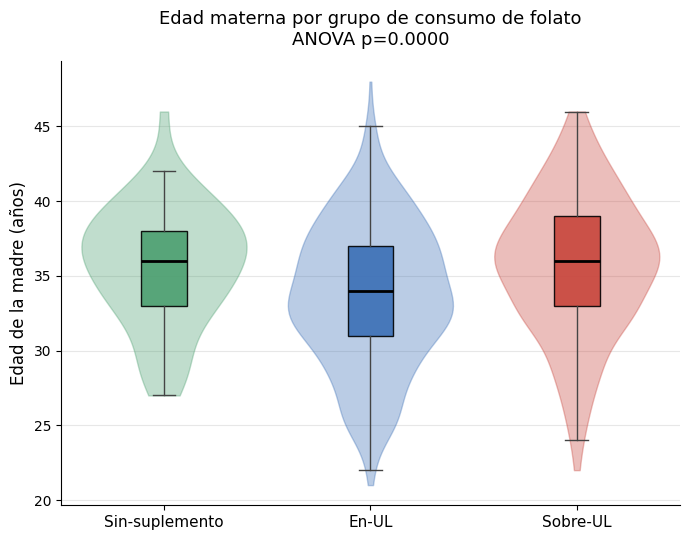

In [23]:

# Violín + boxplot: edad materna por grupo

plt.style.use("default")
plt.rcParams["figure.facecolor"]  = "white"
plt.rcParams["axes.facecolor"]    = "white"
plt.rcParams["savefig.facecolor"] = "white"

PAL = {"Sin-suplemento": "#4C9F70", "En-UL": "#3B6FB6", "Sobre-UL": "#C8453C"}
ORD = ["Sin-suplemento", "En-UL", "Sobre-UL"]

data = [df.loc[df.esquemaA_UL == g, "Edad madre"].dropna().values for g in ORD]
p_edad = stats.f_oneway(*data).pvalue

fig, ax = plt.subplots(figsize=(7, 5.5))
vp = ax.violinplot(data, showmeans=False, showmedians=False, showextrema=False, widths=0.8)
for b, g in zip(vp["bodies"], ORD):
    b.set_facecolor(PAL[g]); b.set_alpha(0.35); b.set_edgecolor(PAL[g])
bp = ax.boxplot(data, patch_artist=True, widths=0.22, showfliers=False,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(color="#444"), capprops=dict(color="#444"))
for p, g in zip(bp["boxes"], ORD):
    p.set_facecolor(PAL[g]); p.set_alpha(0.9)

ax.set_xticks(range(1, len(ORD)+1)); ax.set_xticklabels(ORD, fontsize=11)
ax.set_ylabel("Edad de la madre (años)", fontsize=12)
ax.set_title(f"Edad materna por grupo de consumo de folato\nANOVA p={p_edad:.4f}",
             fontsize=13, pad=12)
ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("grafico_edad_violin.png", dpi=150, bbox_inches="tight")
plt.show()

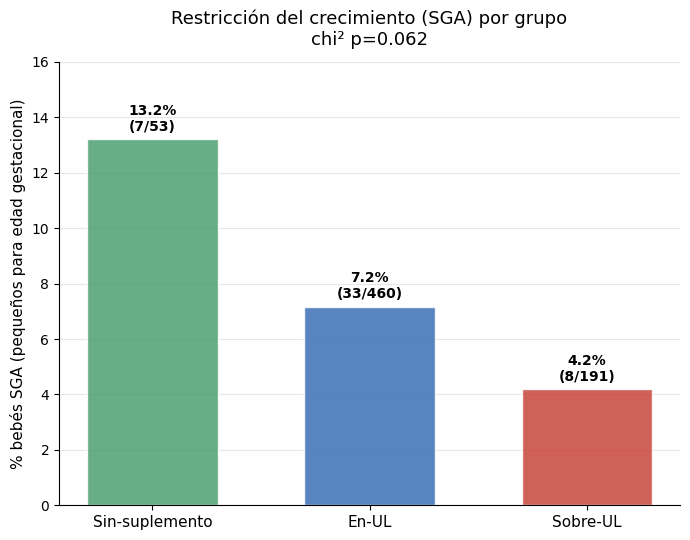

In [24]:
# Barras: % SGA (restricción de crecimiento) por grupo
plt.style.use("default")
plt.rcParams["figure.facecolor"]  = "white"
plt.rcParams["axes.facecolor"]    = "white"
plt.rcParams["savefig.facecolor"] = "white"

sub = df[df["z_peso_fenton"].notna()]
pcts = [100 * sub.loc[sub.esquemaA_UL == g, "es_SGA"].mean() for g in ORD]
ns   = [int(sub.loc[sub.esquemaA_UL == g, "es_SGA"].sum()) for g in ORD]
tots = [len(sub.loc[sub.esquemaA_UL == g]) for g in ORD]

tab = pd.crosstab(sub.esquemaA_UL, sub.es_SGA)
_, p_sga, _, _ = stats.chi2_contingency(tab)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.bar(range(len(ORD)), pcts, color=[PAL[g] for g in ORD], alpha=0.85,
       edgecolor="white", width=0.6)
for i, (p, n, t) in enumerate(zip(pcts, ns, tots)):
    ax.text(i, p + 0.3, f"{p:.1f}%\n({n}/{t})", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(ORD))); ax.set_xticklabels(ORD, fontsize=11)
ax.set_ylabel("% bebés SGA (pequeños para edad gestacional)", fontsize=11)
ax.set_title(f"Restricción del crecimiento (SGA) por grupo\nchi² p={p_sga:.3f}",
             fontsize=13, pad=12)
ax.set_ylim(0, 16); ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("grafico_sga_por_grupo.png", dpi=150, bbox_inches="tight")
plt.show()